In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("bank-full.csv", sep=";")
print("Shape:", df.shape)
print(df.head())

Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


# **EDA and Cleaning**

In [6]:
# Missing Values
print(df.isnull().sum())

# Duplicate values

print("Duplicates:", df.duplicated().sum())

# Check 'Unknown' Values
print("\n=== 'Unknown' Value Counts per Column ===")
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
for col in cat_cols:
    unknown = (df[col] == 'unknown').sum()
    pct = round(unknown / len(df) * 100, 2)
    print(f"  {col}: {unknown} unknowns ({pct}%)")

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Duplicates: 0

=== 'Unknown' Value Counts per Column ===
  job: 288 unknowns (0.64%)
  marital: 0 unknowns (0.0%)
  education: 1857 unknowns (4.11%)
  default: 0 unknowns (0.0%)
  housing: 0 unknowns (0.0%)
  loan: 0 unknowns (0.0%)
  contact: 13020 unknowns (28.8%)
  poutcome: 36959 unknowns (81.75%)


In [7]:
# Check Outliers
for col in ['balance', 'duration', 'campaign']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outliers | min={df[col].min()} | max={df[col].max()}")

  balance: 4729 outliers | min=-8019 | max=102127
  duration: 3235 outliers | min=0 | max=4918
  campaign: 3064 outliers | min=1 | max=63


In [9]:
# Check pdays Column
print("pdays: -1 means never previously contacted ===")
print("-1 count:", (df['pdays'] == -1).sum())
print("As % of data:", round((df['pdays'] == -1).sum() / len(df) * 100, 2), "%")

pdays: -1 means never previously contacted ===
-1 count: 36954
As % of data: 81.74 %


In [11]:
# Check Target Variable Distribution

print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).round(3) * 100)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


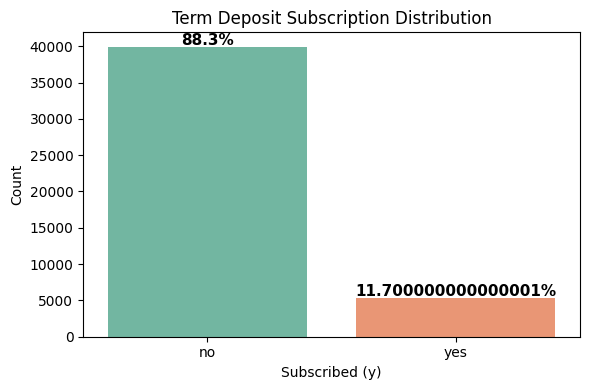

In [12]:
# Target Distribution Plot
counts = df['y'].value_counts()
pcts = df['y'].value_counts(normalize=True).round(3) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index, y=counts.values,
                 hue=counts.index, legend=False, palette='Set2')

for i, (count, pct) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, count + 300, f"{pct}%", ha='center', fontsize=11, fontweight='bold')

plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

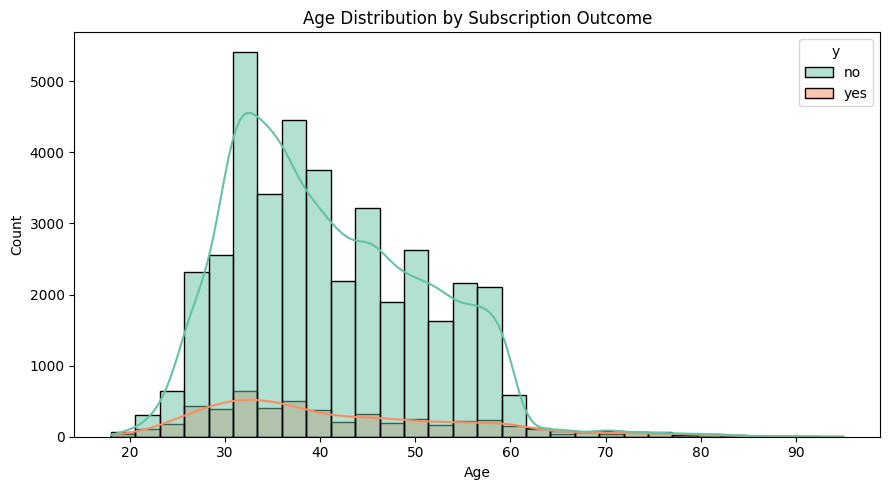

       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39922.0  40.838986  10.172662  18.0  33.0  39.0  48.0  95.0
yes   5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


In [13]:
# Age Distribution by Subscription
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, palette='Set2')
plt.title('Age Distribution by Subscription Outcome')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df.groupby('y')['age'].describe())

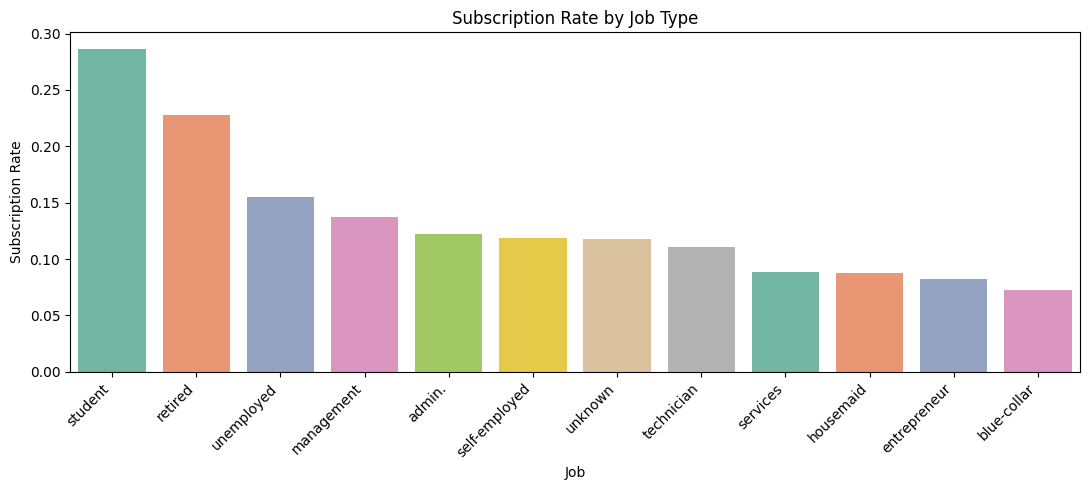

In [14]:
# Subscription Rate by Job
job_rate = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x)
).sort_values(ascending=False).reset_index()
job_rate.columns = ['job', 'subscription_rate']

plt.figure(figsize=(11, 5))
sns.barplot(data=job_rate, x='job', y='subscription_rate',
            hue='job', legend=False, palette='Set2')
plt.title('Subscription Rate by Job Type')
plt.xlabel('Job')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

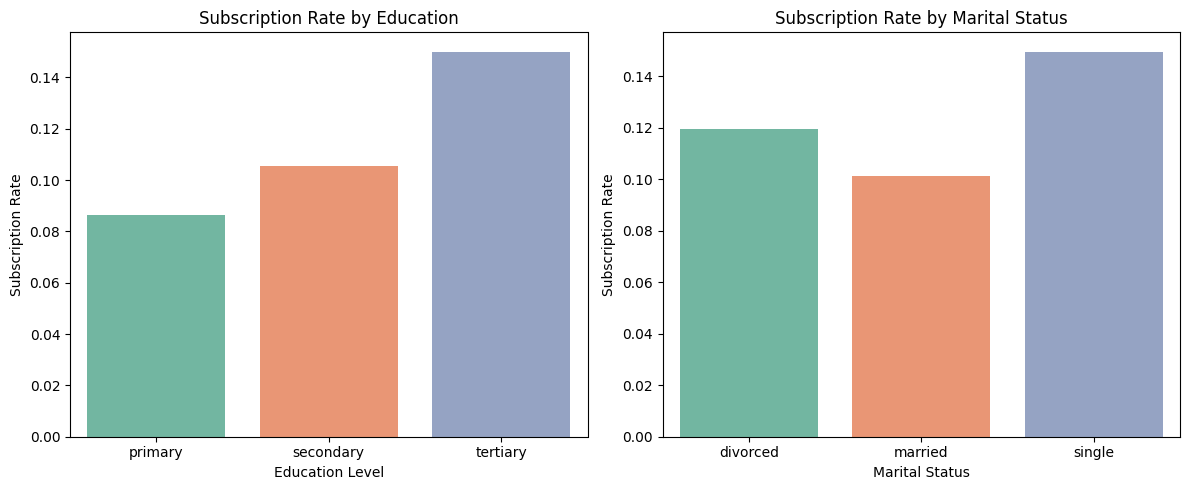

In [15]:
# Subscription Rate by Education & Marital Status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Education
edu_order = ['primary', 'secondary', 'tertiary']
edu_rate = df[df['education'].isin(edu_order)].groupby('education')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x)
).reindex(edu_order).reset_index()
edu_rate.columns = ['education', 'subscription_rate']

sns.barplot(data=edu_rate, x='education', y='subscription_rate',
            hue='education', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Subscription Rate by Education')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Subscription Rate')

# Marital Status
marital_rate = df.groupby('marital')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x)
).reset_index()
marital_rate.columns = ['marital', 'subscription_rate']

sns.barplot(data=marital_rate, x='marital', y='subscription_rate',
            hue='marital', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Subscription Rate by Marital Status')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Subscription Rate')

plt.tight_layout()
plt.show()


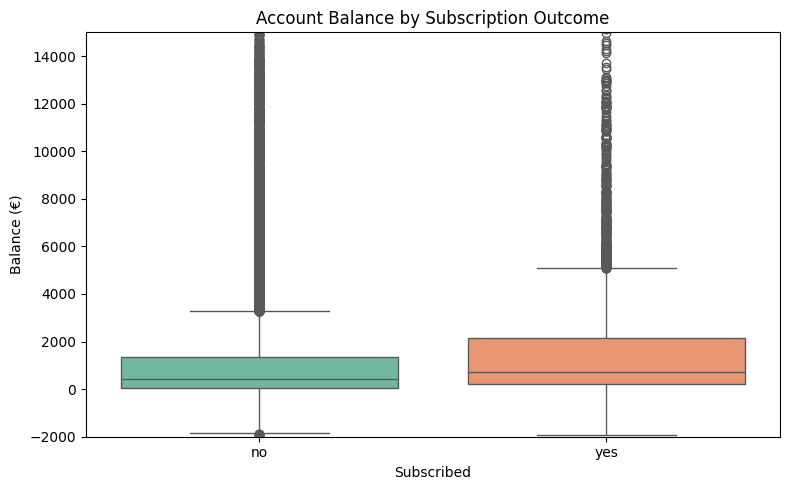

       count         mean          std     min    25%    50%     75%       max
y                                                                             
no   39922.0  1303.714969  2974.195473 -8019.0   58.0  417.0  1345.0  102127.0
yes   5289.0  1804.267915  3501.104777 -3058.0  210.0  733.0  2159.0   81204.0


In [16]:
# Balance by Subscription
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='balance',
            hue='y', legend=False, palette='Set2')
plt.title('Account Balance by Subscription Outcome')
plt.xlabel('Subscribed')
plt.ylabel('Balance (€)')
plt.ylim(-2000, 15000)
plt.tight_layout()
plt.show()

print(df.groupby('y')['balance'].describe())

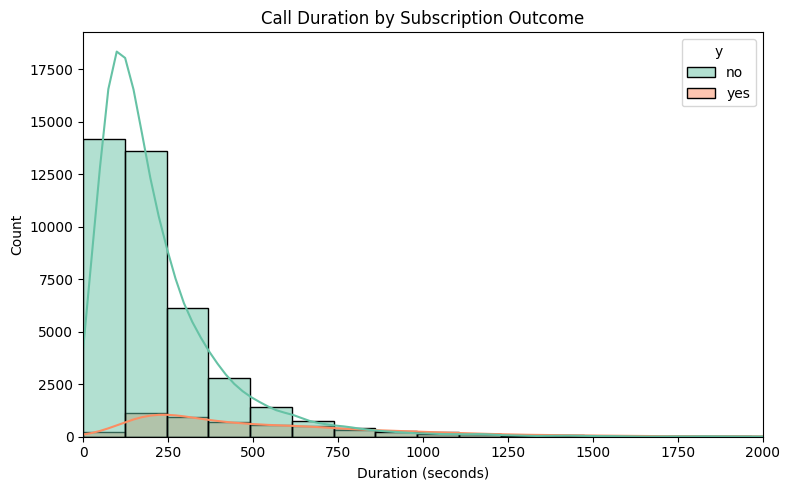

       count        mean         std  min    25%    50%    75%     max
y                                                                     
no   39922.0  221.182806  207.383237  0.0   95.0  164.0  279.0  4918.0
yes   5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0


In [17]:
# Call Duration by Subscription
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='duration', hue='y', bins=40, kde=True, palette='Set2')
plt.title('Call Duration by Subscription Outcome')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(df.groupby('y')['duration'].describe())

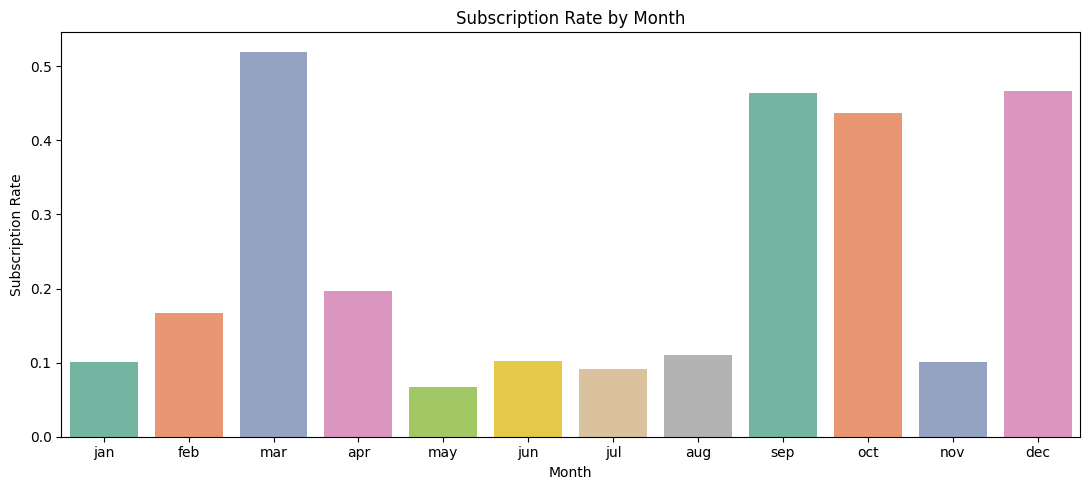

In [18]:
# Subscription Rate by Month
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_rate = df.groupby('month')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x)
).reindex(month_order).reset_index()
month_rate.columns = ['month', 'subscription_rate']

plt.figure(figsize=(11, 5))
sns.barplot(data=month_rate, x='month', y='subscription_rate',
            hue='month', legend=False, palette='Set2')
plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate')
plt.tight_layout()
plt.show()

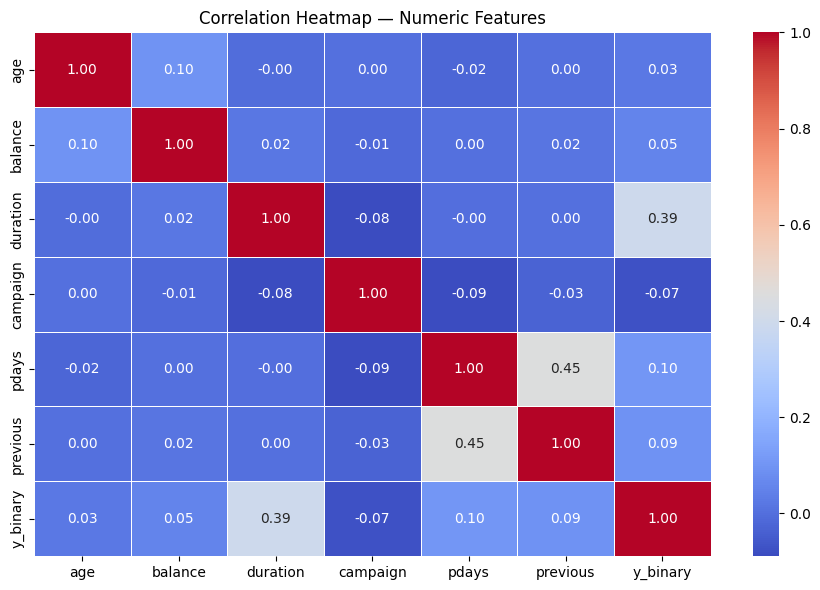

In [19]:
# Correlation Heatmap
df_temp = df.copy()
df_temp['y_binary'] = df_temp['y'].map({'yes': 1, 'no': 0})

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y_binary']

plt.figure(figsize=(9, 6))
sns.heatmap(df_temp[num_cols].corr(), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

In [20]:
# Cleaning: Replace 'unknown' in job & education
# Only job (0.6%) and education (4.1%) are safe to impute
# contact (28.8%) and poutcome (81.7%) are kept as-is

for col in ['job', 'education']:
    mode_val = df[col][df[col] != 'unknown'].mode()[0]
    before = (df[col] == 'unknown').sum()
    df[col] = df[col].replace('unknown', mode_val)
    print(f"{col}: replaced {before} unknowns with '{mode_val}'")

job: replaced 288 unknowns with 'blue-collar'
education: replaced 1857 unknowns with 'secondary'


In [21]:
# Cleaning: Fix pdays
# Create a flag column to preserve the "never contacted" info
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)


# Replace -1 with 0
df['pdays'] = df['pdays'].replace(-1, 0)

print("Previously contacted:\n", df['was_previously_contacted'].value_counts())

Previously contacted:
 was_previously_contacted
0    36954
1     8257
Name: count, dtype: int64


In [22]:
# Cleaning: Add Binary Target Column
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})
print("y_binary:\n", df['y_binary'].value_counts())

y_binary:
 y_binary
0    39922
1     5289
Name: count, dtype: int64


In [23]:
# print("=== Final Shape:", df.shape)
print("\nAny nulls?\n", df.isnull().sum())
print("\nSample:\n", df.head())


Any nulls?
 age                         0
job                         0
marital                     0
education                   0
default                     0
balance                     0
housing                     0
loan                        0
contact                     0
day                         0
month                       0
duration                    0
campaign                    0
pdays                       0
previous                    0
poutcome                    0
y                           0
was_previously_contacted    0
y_binary                    0
dtype: int64

Sample:
    age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married  secondary      no     1506     yes   no   
4   33   blue-collar   s

In [24]:
df.to_csv("bank_full_cleaned.csv", index=False)
print("✅ Saved: bank_full_cleaned.csv")

✅ Saved: bank_full_cleaned.csv
